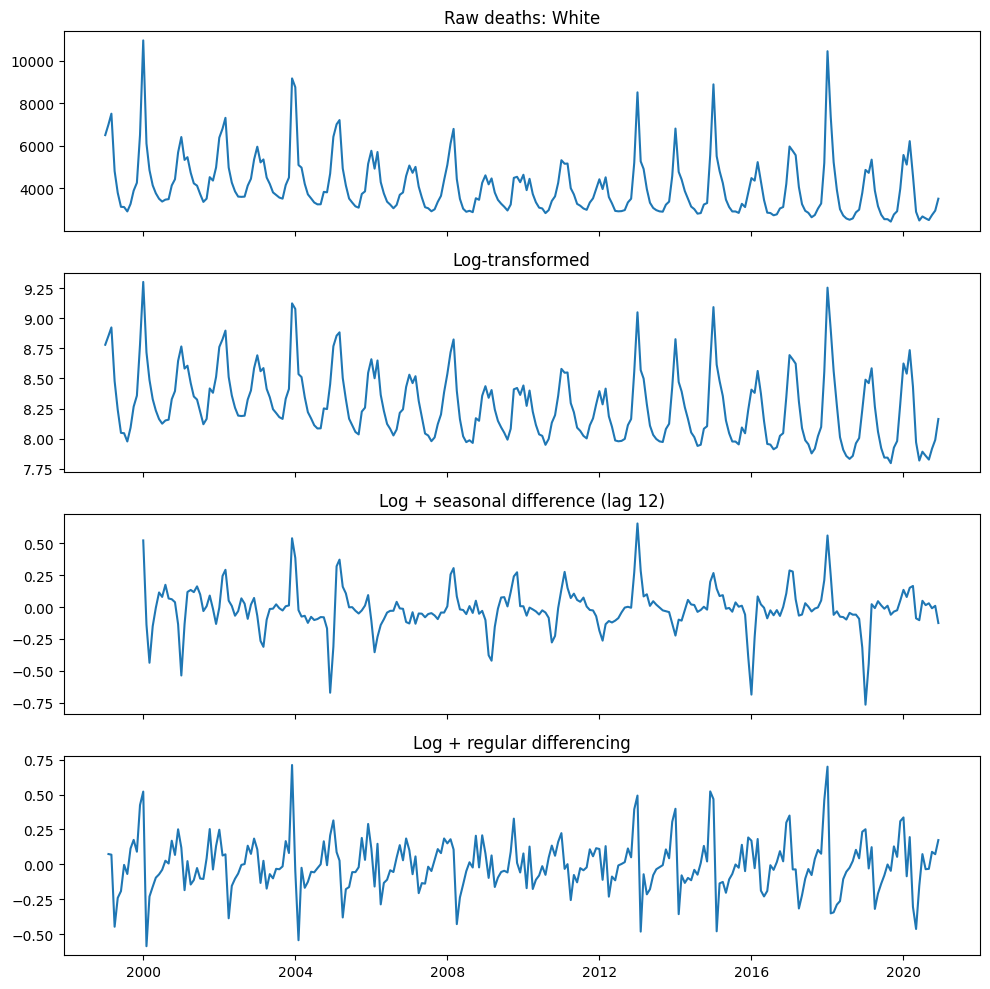

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
# load data
df = pd.read_csv("~Fionn/Downloads/Group_By_Race.csv")

# parse month like "Jan, 1999"
df["Date"] = pd.to_datetime(df["Month"], format="%b, %Y")

# pick one race
race_name = "White"
sub = (
    df[df["Race"] == race_name]
    .sort_values("Date")
    .copy()
)

# make a monthly time series
ts = sub.set_index("Date")["Deaths"].asfreq("MS")
# 1) variance-stabilizing transform
log_ts = np.log(ts).dropna()

# 2) seasonal differencing (monthly seasonality)
seasonal_diff = log_ts.diff(12)

# 3) regular differencing to remove remaining trend
#stationary_ts = seasonal_diff.diff(1) get rid of for now

# drop missing values from differencing
stationary_ts = seasonal_diff.dropna()
#stationary_ts = log_ts.diff(1).dropna()

# quick plots
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

axes[0].plot(ts)
axes[0].set_title(f"Raw deaths: {race_name}")

axes[1].plot(log_ts)
axes[1].set_title("Log-transformed")

axes[2].plot(seasonal_diff)
axes[2].set_title("Log + seasonal difference (lag 12)")

axes[3].plot(log_ts.diff(1).dropna())
axes[3].set_title("Log + regular differencing")

plt.tight_layout()
plt.savefig("figures/eda_White_transforms.png", dpi=300, bbox_inches="tight")
plt.show()



In [112]:
import os
os.makedirs("figures", exist_ok=True)

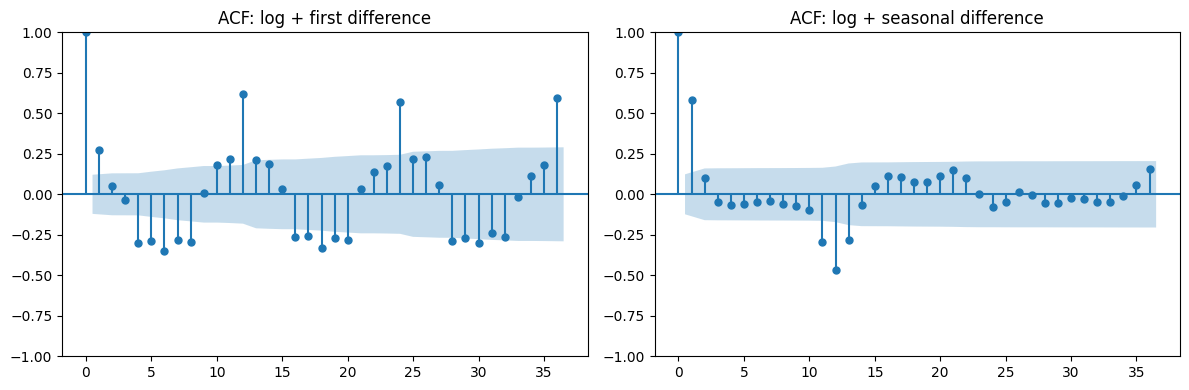

In [113]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ACF for log + first difference
plot_acf(np.log(ts).diff(1).dropna(), lags=36, ax=axes[0])
axes[0].set_title("ACF: log + first difference")

# ACF for log + seasonal difference
plot_acf(stationary_ts, lags=36, ax=axes[1])
axes[1].set_title("ACF: log + seasonal difference")

plt.tight_layout()
plt.savefig("data_acf_white.png", dpi=300, bbox_inches="tight")
plt.show()

In [114]:
import os
print(os.getcwd())

/Users/Fionn/531-final-project/531-final-project-7


In [115]:
# ADF test
adf_stat, pval, *_ = adfuller(log_ts.diff(1).dropna())
print("ADF statistic for log+first difference:", adf_stat)
print("ADF p-value for log+first difference::", pval)

adf_stat, pval, *_ = adfuller(stationary_ts)
print("ADF statistic for log+seasonal difference ", adf_stat)
print("ADF p-value forlog+seasonal difference  ", pval)
#both transforms give stationary data, but seasonal difference gives a better looking acf

ADF statistic for log+first difference: -7.01725123935279
ADF p-value for log+first difference:: 6.683297656614427e-10
ADF statistic for log+seasonal difference  -5.266020765941257
ADF p-value forlog+seasonal difference   6.436510092141013e-06


In [116]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA



results = []

for p in range(6):
    for q in range(6):
        try:
            fit = ARIMA(
                stationary_ts,
                order=(p, 0, q),
                enforce_stationarity=True,
                enforce_invertibility=True
            ).fit(method_kwargs={"maxiter": 300})

            results.append({
                "p": p,
                "q": q,
                "AIC": fit.aic,
                "loglik": fit.llf,
                "converged": fit.mle_retvals.get("converged", None),
                "iterations": fit.mle_retvals.get("iterations", None)
            })

        except Exception as e:
            results.append({
                "p": p,
                "q": q,
                "AIC": None,
                "loglik": None,
                "converged": False,
                "iterations": None
            })

results_df = pd.DataFrame(results)
good_df = results_df[results_df["AIC"].notna()].sort_values(["converged", "AIC"], ascending=[False, True])
print(good_df)
#choose model with best AIC subject to q \leq 1 as else MA roots are near non invertable

/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


    p  q         AIC      loglik  converged  iterations
23  3  5 -351.474540  185.737270       True         108
29  4  5 -348.563617  185.281809       True         207
28  4  4 -347.765775  183.882887       True         229
33  5  3 -347.165381  183.582690       True         247
35  5  5 -346.549663  185.274832       True         235
27  4  3 -339.883386  178.941693       True         109
9   1  3 -339.837748  175.918874       True          73
22  3  4 -339.106058  178.553029       True         240
14  2  2 -338.097081  175.048540       True          79
15  2  3 -337.958082  175.979041       True          90
10  1  4 -337.926295  175.963147       True          84
20  3  2 -337.490315  175.745158       True          91
21  3  3 -337.175944  176.587972       True          76
11  1  5 -336.609367  176.304683       True         126
16  2  4 -336.302560  176.151280       True         145
17  2  5 -336.177294  177.088647       True         155
26  4  2 -335.830601  175.915300       True     

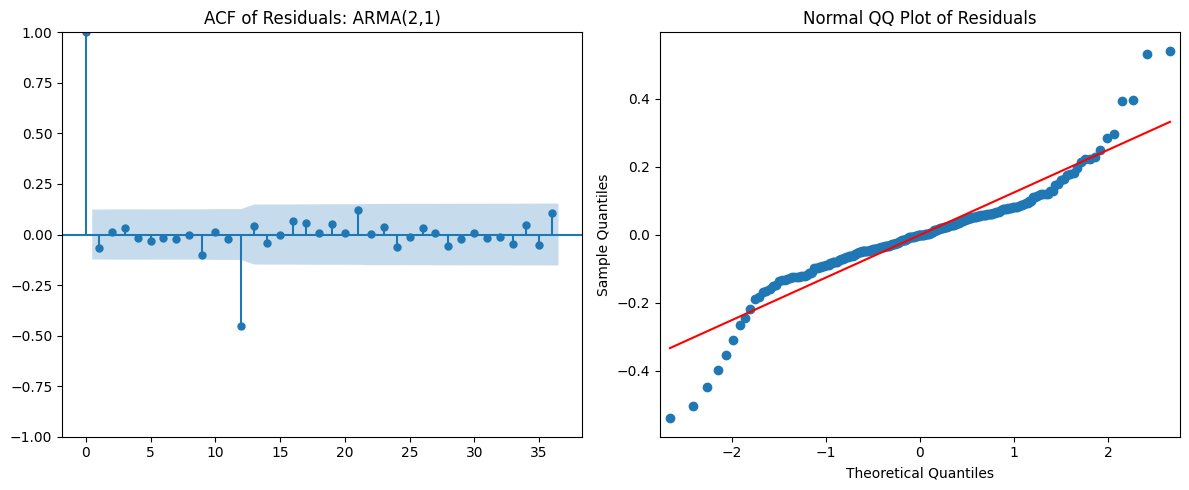

const    -0.010739
ar.L1     0.470306
ar.L2    -0.188369
ma.L1     0.496336
sigma2    0.014939
dtype: float64
[2.01476298]
[2.30406968 2.30406968]

Ljung-Box test:
      lb_stat     lb_pvalue
12  59.405172  2.896854e-08
24  68.666188  3.475059e-06
36  75.824604  1.167007e-04


In [117]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

p=2
q=1
# fit model
fit = ARIMA(
    stationary_ts,
    order=(p, 0, q),
    enforce_stationarity=True,
    enforce_invertibility=True
).fit(method_kwargs={"maxiter": 300})

resid = fit.resid

# plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ACF of residuals
plot_acf(resid, ax=axes[0], lags=36)
axes[0].set_title(f"ACF of Residuals: ARMA({p},{q})")

# QQ plot
sm.qqplot(resid, line='s', ax=axes[1])
axes[1].set_title("Normal QQ Plot of Residuals")

plt.tight_layout()
plt.show()
print(fit.params)
#check roots for invertability
print(np.abs(fit.maroots))
print(np.abs(fit.arroots))
# Ljung-Box test on residuals
lb = acorr_ljungbox(resid, lags=[12, 24, 36], return_df=True)
print("\nLjung-Box test:")
print(lb)
#choose 

In [118]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# make sure this is your revised series:
# stationary_ts = np.log(ts).diff(12).dropna().astype(float)

results = []

for p in range(6):
    for q in range(2):          # start small on nonseasonal MA
        for P in range(2):      # seasonal AR: 0 or 1
            for Q in range(2):  # seasonal MA: 0 or 1
                try:
                    fit = ARIMA(
                        stationary_ts,
                        order=(p, 0, q),
                        seasonal_order=(P, 0, Q, 12),
                        enforce_stationarity=True,
                        enforce_invertibility=True
                    ).fit(method_kwargs={"maxiter": 300})

                    results.append({
                        "p": p,
                        "q": q,
                        "P": P,
                        "Q": Q,
                        "AIC": fit.aic,
                        "loglik": fit.llf,
                        "converged": fit.mle_retvals.get("converged", None)
                    })

                except Exception as e:
                    results.append({
                        "p": p,
                        "q": q,
                        "P": P,
                        "Q": Q,
                        "AIC": None,
                        "loglik": None,
                        "converged": False,
                        "error": str(e)
                    })

results_df = pd.DataFrame(results)

good_df = (
    results_df[results_df["AIC"].notna()]
    .sort_values(["converged", "AIC"], ascending=[False, True])
    .reset_index(drop=True)
)

print(good_df)

/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


    p  q  P  Q         AIC      loglik  converged
0   2  1  0  1 -445.168786  228.584393       True
1   1  1  0  1 -444.108506  227.054253       True
2   4  0  0  1 -443.675097  228.837549       True
3   2  1  1  1 -443.350020  228.675010       True
4   3  1  0  1 -443.270857  228.635428       True
5   1  1  1  1 -442.331191  227.165595       True
6   4  0  1  1 -441.832896  228.916448       True
7   4  1  0  1 -441.676211  228.838106       True
8   5  0  0  1 -441.675987  228.837994       True
9   3  1  1  1 -441.415769  228.707885       True
10  3  0  1  1 -441.311705  227.655852       True
11  4  1  1  1 -439.836837  228.918419       True
12  5  0  1  1 -439.836386  228.918193       True
13  5  1  0  1 -439.677149  228.838575       True
14  2  0  0  1 -437.333197  223.666598       True
15  2  0  1  1 -435.575114  223.787557       True
16  0  1  0  1 -429.332833  218.666416       True
17  0  1  1  1 -427.541434  218.770717       True
18  1  0  1  1 -396.234872  203.117436       True


/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [119]:
p = 2
q = 1
P = 0
Q = 1

fit = ARIMA(
    stationary_ts,
    order=(p, 0, q),
    seasonal_order=(P, 0, Q, 12),
    enforce_stationarity=True,
    enforce_invertibility=True
).fit(method_kwargs={"maxiter": 300})

print(fit.params)
print("AIC:", fit.aic)
print("loglik:", fit.llf)
print("magnitude of AR roots:", np.abs(fit.arroots))
print("magnitude of MA roots:", np.abs(fit.maroots))
#any model with nonzero Q gives near non invertiability 

const      -0.013616
ar.L1       0.485254
ar.L2      -0.175166
ma.L1       0.446010
ma.S.L12   -0.852183
sigma2      0.008938
dtype: float64
AIC: -445.16878626204505
loglik: 228.58439313102252
magnitude of AR roots: [2.38932501 2.38932501]
magnitude of MA roots: [1.0134187 1.0134187 1.0134187 1.0134187 1.0134187 1.0134187 1.0134187
 1.0134187 1.0134187 1.0134187 1.0134187 1.0134187 2.2421023]


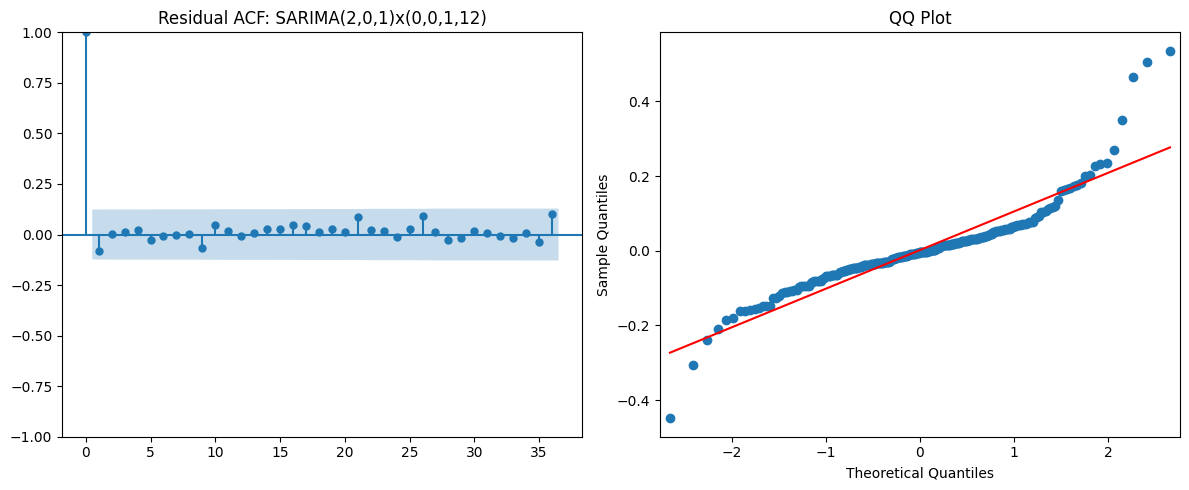


Ljung-Box test:
      lb_stat  lb_pvalue
12   3.977790   0.983834
24   7.995434   0.999089
36  14.379055   0.999509


In [120]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

resid = fit.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_acf(resid, ax=axes[0], lags=36)
axes[0].set_title(f"Residual ACF: SARIMA({p},0,{q})x({P},0,{Q},12)")
sm.qqplot(resid, line="s", ax=axes[1])
axes[1].set_title("QQ Plot")

plt.tight_layout()
plt.savefig("figures/sarima_white_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()
#so sarima give better AIC and better diagnostics via the ACF but model is weakly
#idenfited and residuals are still more heavy tailed than gaussian errors allows for
# Ljung-Box test on residuals
lb = acorr_ljungbox(resid, lags=[12, 24, 36], return_df=True)
print("\nLjung-Box test:")
print(lb)


In [121]:
arma_specs = {
    "American Indian or Alaska Native":  (2, 0),
    "Asian or Pacific Islander":  (1, 0),
    "Black or African American":  (5, 1),
    "White":  (2, 1),
}

sarima_specs = {
    "American Indian or Alaska Native":  (2, 0, 0, 1),   # (p,q,P,Q)
    "Asian or Pacific Islander":  (1, 0, 0, 1),
    "Black or African American":  (4, 0, 0, 1),
    "White":  (2, 1, 0, 1),
}

In [122]:
import numpy as np
import pandas as pd

def make_stationary_series(df, race_name):
    sub = (
        df[df["Race"] == race_name]
        .sort_values("Date")
        .copy()
    )
    
    ts = sub.set_index("Date")["Deaths"].asfreq("MS")
    
    log_ts = np.log(ts).dropna()
    
    # your chosen transformation (seasonal differencing)
    stationary_ts = log_ts.diff(12).dropna().astype(float)
    
    return ts, log_ts, stationary_ts

In [123]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
arma_rows = []

for race, (p, q) in arma_specs.items():
    _, _, stationary_ts = make_stationary_series(df, race)

    fit = ARIMA(
        stationary_ts,
        order=(p, 0, q),
        enforce_stationarity=True,
        enforce_invertibility=True
    ).fit(method_kwargs={"maxiter": 300})

    resid = fit.resid
    lb = acorr_ljungbox(resid, lags=[36], return_df=True)

    row = {
        "Race": race,
        "Model": f"ARMA({p},{q})",
        "AIC": fit.aic,
        "loglik": fit.llf,
        "LB p(36)": lb.loc[36, "lb_pvalue"],
        "min AR root": np.min(np.abs(fit.arroots)) if len(fit.arroots) > 0 else np.nan,
        "min MA root": np.min(np.abs(fit.maroots)) if len(fit.maroots) > 0 else np.nan
    }

    for k, v in fit.params.items():
        if k not in ["const", "sigma2"]:
            row[k] = v

    arma_rows.append(row)

arma_table = pd.DataFrame(arma_rows).round(4)
arma_table

/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,Race,Model,AIC,loglik,LB p(36),min AR root,min MA root,ar.L1,ar.L2,ar.L3,ar.L4,ar.L5,ma.L1
0,American Indian or Alaska Native,"ARMA(2,0)",178.9865,-85.4932,0.0000,1.9111,NaN,0.2409,0.1478,NaN,NaN,NaN,NaN
1,Asian or Pacific Islander,"ARMA(1,0)",-129.5877,67.7939,0.0000,2.7421,NaN,0.3647,NaN,NaN,NaN,NaN,NaN
2,Black or African American,"ARMA(5,1)",-316.4206,166.2103,0.0002,1.1306,1.0920,1.5299,-0.7575,0.0934,0.2847,-0.2433,-0.9157
3,White,"ARMA(2,1)",-333.1659,171.5830,0.0001,2.3041,2.0148,0.4703,-0.1884,NaN,NaN,NaN,0.4963


In [124]:
import os
import dataframe_image as dfi

os.makedirs("figures", exist_ok=True)

# optional: make columns a little cleaner for display
arma_table_display = arma_table.rename(columns={
    "loglik": "logLik",
    "LB p(36)": "LB p(36)",
    "min AR root": "min AR",
    "min MA root": "min MA"
})

dfi.export(arma_table_display, "figures/arma_table.png")

Error: It looks like you are using Playwright Sync API inside the asyncio loop.
Please use the Async API instead.

In [ ]:
import sys
!{sys.executable} -m pip install dataframe_image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 23.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 854.0/854.0 kB 34.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 21.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 14.3 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [dataframe_image] [dataframe_image]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [126]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_rows = []

for race, (p, q, P, Q) in sarima_specs.items():
    _, _, stationary_ts = make_stationary_series(df, race)

    fit = ARIMA(
                        stationary_ts,
                        order=(p, 0, q),
                        seasonal_order=(P, 0, Q, 12),
                        enforce_stationarity=True,
                        enforce_invertibility=True
                    ).fit(method_kwargs={"maxiter": 300})

    resid = fit.resid
    lb = acorr_ljungbox(resid, lags=[36], return_df=True)

    ar_roots = np.abs(fit.arroots) if len(fit.arroots) > 0 else np.array([np.nan])
    ma_roots = np.abs(fit.maroots) if len(fit.maroots) > 0 else np.array([np.nan])

    sarima_rows.append({
        "Race": race,
        "Model": f"SARIMA({p},0,{q})x({P},0,{Q},12)",
        "AIC": fit.aic,
        "loglik": fit.llf,
        "min AR root": np.min(ar_roots),
        "min MA root": np.min(ma_roots)
    })

sarima_table = pd.DataFrame(sarima_rows).round(4)
sarima_table

/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,Race,Model,AIC,loglik,min AR root,min MA root
0,American Indian or Alaska Native,"SARIMA(2,0,0)x(0,0,1,12)",66.9496,-28.4748,1.9748,1.0166
1,Asian or Pacific Islander,"SARIMA(1,0,0)x(0,0,1,12)",-233.2886,120.6443,2.1257,1.0137
2,Black or African American,"SARIMA(4,0,0)x(0,0,1,12)",-417.9640,215.9820,1.3288,1.0158
3,White,"SARIMA(2,0,1)x(0,0,1,12)",-445.1688,228.5844,2.3893,1.0134


/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


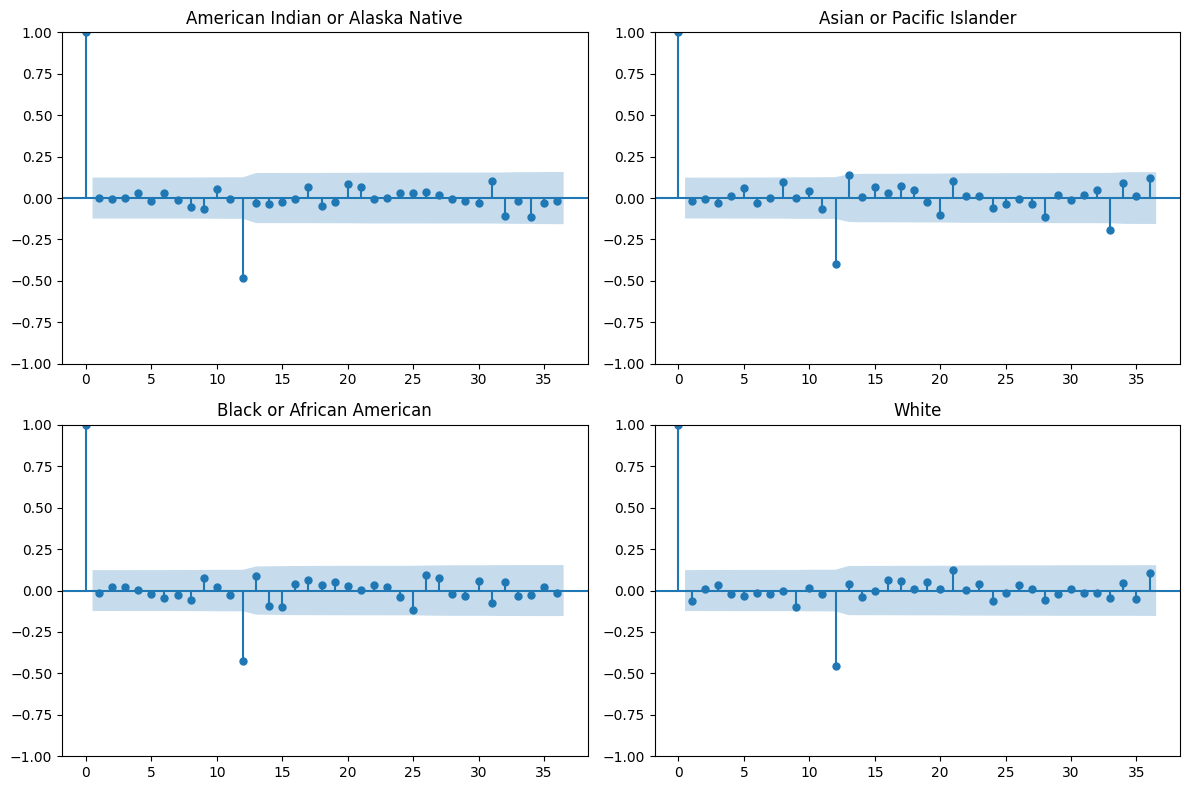

/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/Fionn/jupyter-py/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


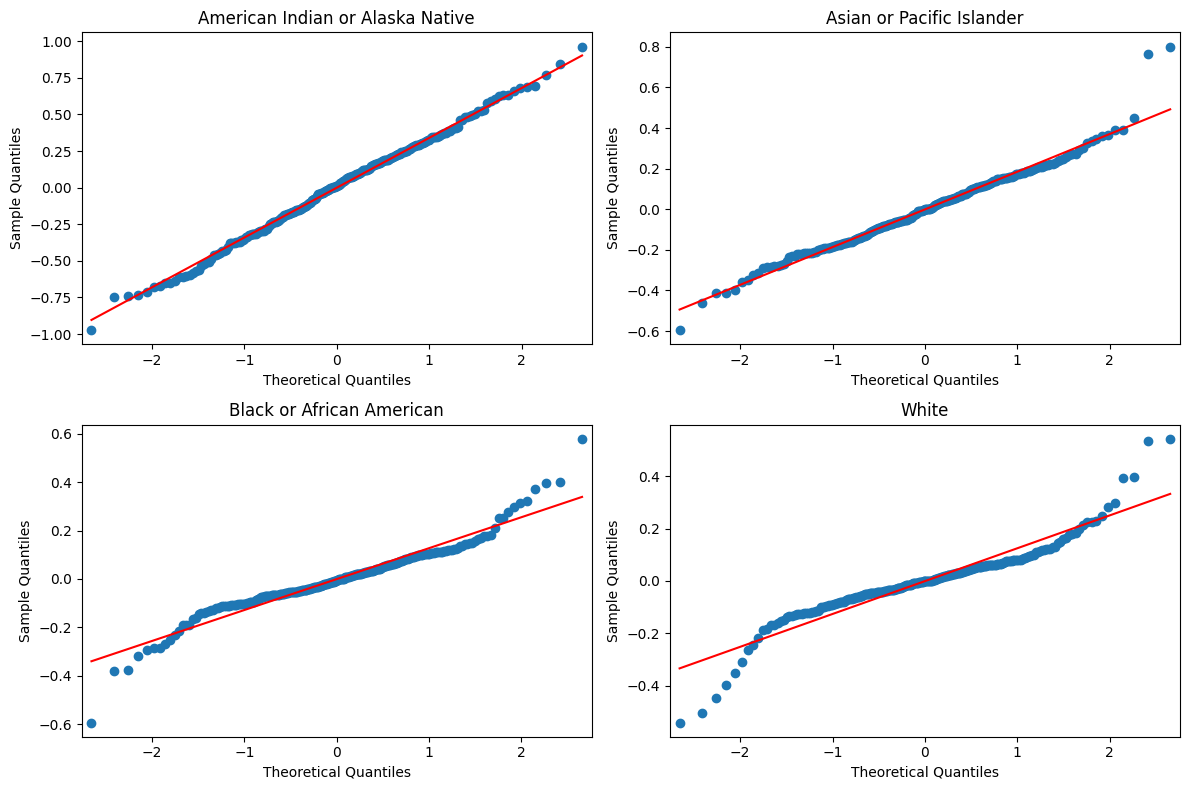

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (race, (p, q, P, Q)) in zip(axes, sarima_specs.items()):
    _, _, stationary_ts = make_stationary_series(df, race)

    # fit EXACTLY like your ARMA-on-differenced-data setup
    fit = ARIMA(
        stationary_ts,
        order=(p, 0, q),
        enforce_stationarity=True,
        enforce_invertibility=True
    ).fit(method_kwargs={"maxiter": 300})

    resid = fit.resid

    plot_acf(resid, ax=ax, lags=36)
    ax.set_title(f"{race}")

plt.tight_layout()
plt.savefig("figures/ARMA_acf_byrace.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (race, (p, q, P, Q)) in zip(axes, sarima_specs.items()):
    _, _, stationary_ts = make_stationary_series(df, race)

    fit = ARIMA(
        stationary_ts,
        order=(p, 0, q),
        enforce_stationarity=True,
        enforce_invertibility=True
    ).fit(method_kwargs={"maxiter": 300})

    resid = fit.resid

    sm.qqplot(resid, line='s', ax=ax)
    ax.set_title(f"{race}")

plt.tight_layout()
plt.savefig("figures/ARMA_QQ_byrace.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# assuming df has columns: Date, Deaths, Race

summary_rows = []

for race, sub in df.groupby("Race"):
    ts = sub.set_index("Date")["Deaths"].asfreq("MS").dropna()

    n = len(ts)
    mean = ts.mean()
    std = ts.std()
    min_val = ts.min()
    max_val = ts.max()
    cv = std / mean

    log_mean = np.log(ts).mean()

    summary_rows.append({
        "Race": race,
        "n(months)": n,
        "Mean": mean,
        "SD": std,
        "Min": min_val,
        "Max": max_val,
        "CV": cv,
        "Mean log(deaths)": log_mean
    })

summary_df = pd.DataFrame(summary_rows)

# clean formatting
summary_df = summary_df.round({
    "Mean": 1,
    "SD": 1,
    "Min": 0,
    "Max": 0,
    "CV": 3,
    "Mean log(deaths)": 3
})

summary_df = summary_df.sort_values("Mean", ascending=False)

summary_df

,Race,n(months),Mean,SD,Min,Max,CV,Mean log(deaths)
3,White,264,4126.1,1373.8,2432.0,10960.0,0.333,8.280
2,Black or African American,264,469.5,119.1,322.0,1145.0,0.254,6.125
1,Asian or Pacific Islander,264,136.5,55.5,28.0,479.0,0.407,4.845
0,American Indian or Alaska Native,263,29.7,12.6,10.0,89.0,0.423,3.313


In [ ]:
print(summary_df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{lrrrrrrr}
\toprule
Race & n(months) & Mean & SD & Min & Max & CV & Mean log(deaths) \\
\midrule
White & 264 & 4126.100 & 1373.800 & 2432.000 & 10960.000 & 0.333 & 8.280 \\
Black or African American & 264 & 469.500 & 119.100 & 322.000 & 1145.000 & 0.254 & 6.125 \\
Asian or Pacific Islander & 264 & 136.500 & 55.500 & 28.000 & 479.000 & 0.407 & 4.845 \\
American Indian or Alaska Native & 263 & 29.700 & 12.600 & 10.000 & 89.000 & 0.423 & 3.313 \\
\bottomrule
\end{tabular}

